### ***Exploratory Data Analysis On CLeaned AC Dataset***

### ***Column Reference***

Quick map of all 22 columns in `ac_cleaned.parquet` (994 rows). Use this as a reference while exploring.

#### Categorical (3 columns)

| Column | Description |
| --- | --- |
| `brand` | Manufacturer name. 33+ brands (Voltas, LG, Samsung, etc.). |
| `product` | Appliance category. **Constant `"AC"`** today — only ACs scraped. Future-proofed for other appliances. |
| `ac_type` | AC form factor. Two values: `Split` (905) and `Window` (107). |

#### Numeric — Continuous (2 columns)

| Column | Description |
| --- | --- |
| `price` | **TARGET.** Marketplace price in INR. Range: ₹19,990 – ₹86,990. |
| `user_rating` | Customer rating on 5-point scale. Range: 3.15 – 4.75 (narrow band — most ACs rate 4.0+). |

#### Numeric — Discrete (17 columns)

| Column | Description |
| --- | --- |
| `capacity` | AC capacity in tons. Standard sizes: 0.75, 1.0, 1.2, 1.5, 1.6, 1.8, 2.0, 2.5, 3.0. |
| `model_year` | Year of manufacture (extracted from name). **831/994 non-null** (16.4% missing). Range: 2019–2025. |
| `star_rating` | BEE energy rating (1–5). Higher = more efficient. |
| `inverter` | Binary: 1 = inverter tech, 0 = non-inverter. |
| `Dehumidification` | Binary: 1 = has moisture-removal mode. |
| `Turbo Mode` | Binary: 1 = has fast-cooling turbo mode. |
| `Air Swing` | Binary: 1 = has auto air-swing (combines 2-way and 4-way). |
| `Self Diagnosis` | Binary: 1 = AC can self-diagnose faults. |
| `Memory Feature` | Binary: 1 = remembers last settings after power-off. |
| `LED Panel Display` | Binary: 1 = has LED display on the unit. |
| `Night Glow Buttons` | Binary: 1 = backlit remote buttons. |
| `Wi-Fi Connectivity` | Binary: 1 = Wi-Fi enabled. |
| `APP Control` | Binary: 1 = mobile-app controllable. |
| `Auto Clean` | Binary: 1 = self-cleaning mode. |
| `Hidden Panel Display` | Binary: 1 = display hides when idle. |
| `Voice Control` | Binary: 1 = voice-assistant compatible. |
| `PM 2.5 Filter` | Binary: 1 = has PM 2.5 air filter. |

**Total: 22 columns** (3 categorical + 19 numeric: 2 continuous + 17 discrete, including 14 boolean features + inverter).

**Reminders:**
- `name` was dropped from the cleaned dataset after extracting `brand`, `model_year`, `star_rating`
- `product` is constant today — not useful for modeling now, but kept for future multi-appliance support
- `model_year` missingness handled later (brand-median imputation + missing indicator → `age = current_year - model_year`)

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook')
import warnings

warnings.filterwarnings('ignore')

In [12]:
# import the data 

data = pd.read_parquet('D:/Study/data_science/underpriced-listing-predictor/data/03.cleaned/ac_cleaned.parquet')

print(data.head(5))


       brand  model_year product  price  user_rating ac_type  capacity  \
0  Whirlpool        <NA>      AC  24990         4.65   Split       1.5   
1    Carrier        2024      AC  22990         4.55   Split       1.5   
2  O General        <NA>      AC  67990         4.10   Split       1.5   
3      Haier        2025      AC  37990         4.55   Split       1.5   
4     Voltas        <NA>      AC  22990         4.55   Split       1.5   

   Dehumidification  Turbo Mode  Air Swing  ...  LED Panel Display  \
0                 0           1          1  ...                  0   
1                 1           1          0  ...                  0   
2                 1           1          1  ...                  1   
3                 1           1          1  ...                  0   
4                 1           1          1  ...                  0   

   Night Glow Buttons  Wi-Fi Connectivity  APP Control  Auto Clean  \
0                   1                   0            0          

In [13]:
# Basic info about the dataset
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   brand                 994 non-null    str    
 1   model_year            831 non-null    Int64  
 2   product               994 non-null    str    
 3   price                 994 non-null    int64  
 4   user_rating           994 non-null    float32
 5   ac_type               994 non-null    str    
 6   capacity              994 non-null    float32
 7   Dehumidification      994 non-null    int64  
 8   Turbo Mode            994 non-null    int64  
 9   Air Swing             994 non-null    int64  
 10  Self Diagnosis        994 non-null    int64  
 11  Memory Feature        994 non-null    int64  
 12  LED Panel Display     994 non-null    int64  
 13  Night Glow Buttons    994 non-null    int64  
 14  Wi-Fi Connectivity    994 non-null    int64  
 15  APP Control           994 non-null

In [14]:
# Basic stats of each numeric column
print(data.describe().T)

                      count          mean           std      min      25%  \
model_year            831.0   2024.495788      1.418354   2018.0   2023.0   
price                 994.0  40201.465795  10546.750948  19990.0  32999.0   
user_rating           994.0      4.376409      0.236678     3.15     4.15   
capacity              994.0      1.443159      0.322507     0.75     1.05   
Dehumidification      994.0      0.875252        0.3306      0.0      1.0   
Turbo Mode            994.0      0.650905      0.476924      0.0      0.0   
Air Swing             994.0      0.896378      0.304923      0.0      1.0   
Self Diagnosis        994.0      0.467807      0.499214      0.0      0.0   
Memory Feature        994.0      0.203219      0.402597      0.0      0.0   
LED Panel Display     994.0       0.21328       0.40983      0.0      0.0   
Night Glow Buttons    994.0      0.186117      0.389397      0.0      0.0   
Wi-Fi Connectivity    994.0      0.182093      0.386115      0.0      0.0   

In [15]:
# Red flags to look for in the first 5 minutes
red_flags = []
for col in data.columns:
    s = data[col]
    if s.nunique() <= 1:
        red_flags.append(f'{col}: constant column!')
    if s.isnull().mean() > 0.5:
        red_flags.append(f'{col}: > 50% missing!')
    if s.dtype == 'object' and s.nunique() > 0.5 * len(s):
        red_flags.append(f'{col}: looks like a unique identifier')

if not red_flags:
    print('No obvious red flags in the first 5 minutes. ✅')
else:
    for f in red_flags: print(' -', f)

 - product: constant column!


- This is because we only have AC data for now

### ***Univariate Analysis***

**Target Column**

In [ ]:
# Describe the column price
data['price'].describe()

count      994.000000
mean     40201.465795
std      10546.750948
min      19990.000000
25%      32999.000000
50%      37525.500000
75%      44868.250000
max      86990.000000
Name: price, dtype: float64

- Mean AC price is 40201
- Price ranges from 20000  to almost 87000 and 75% of the prices are below 45000, that can easily imply the column has outliers
- Check it With Histogram and QQ Plot

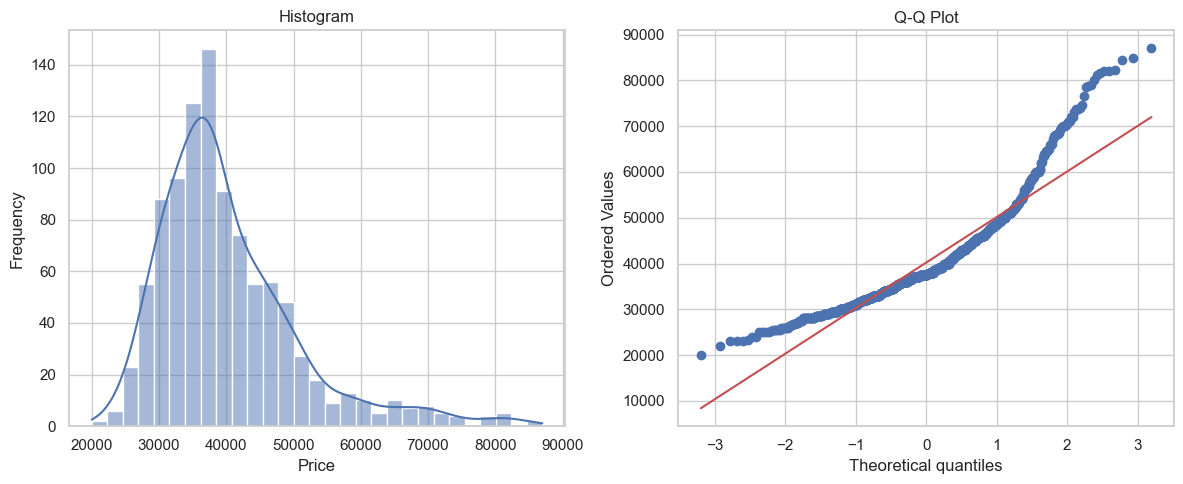

In [17]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(data =data , x ='price' , kde=True, ax=axes[0])
axes[0].set_title('Histogram')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Q-Q Plot
stats.probplot(data['price'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

- Histogram shows a right-skewness in the prices.
- QQ Plot plot suggests that the price column is not perfectly normally distributed

**Let us Check the Log transformed prices**

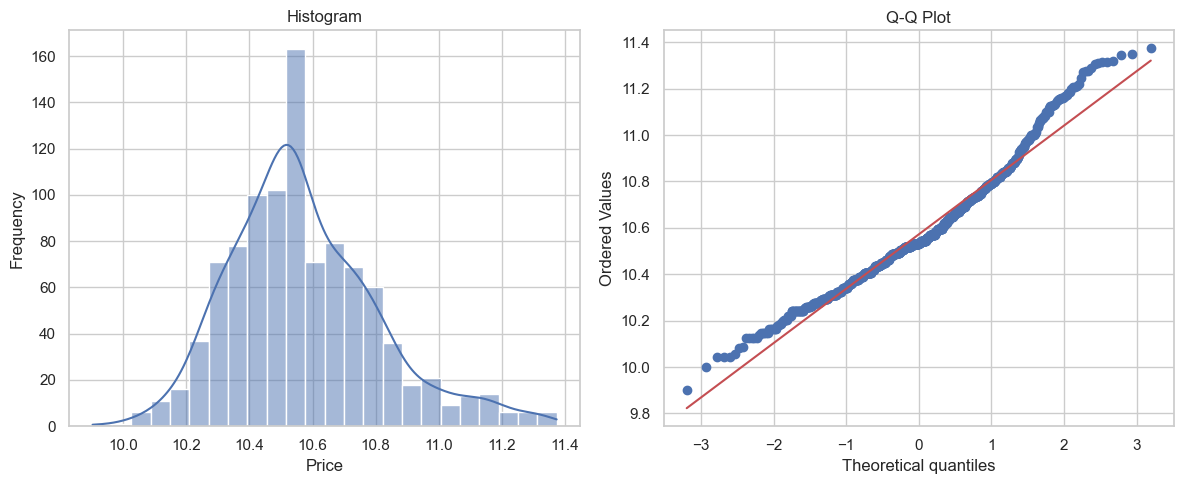

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

log_prices = np.log1p(data['price'])
# Histogram
sns.histplot(x =log_prices , kde=True, ax=axes[0])
axes[0].set_title('Histogram')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Q-Q Plot
stats.probplot(log_prices, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

- Clearly the skewness of the data decreased after we did log transformation.      
**Thus We will log transform our prices before training the linear models**

**Box Plots to Look for Outliers**

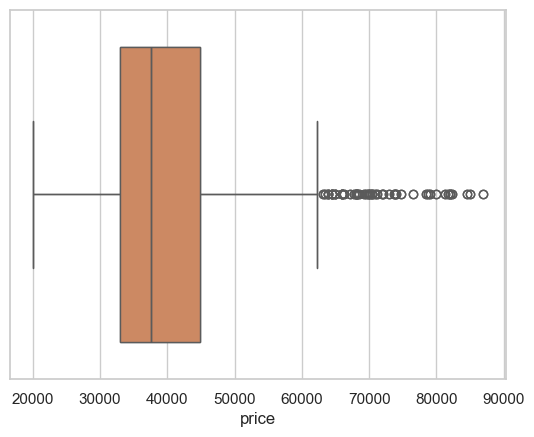

In [20]:
sns.boxplot(data=data , x='price')
plt.show()

In [22]:
# Checking the outlier data
q3 = np.quantile(data['price'],.75)
q1 = np.quantile(data['price'],.25)

lower = q1 - 1.5*(q3-q1)
upper = q3 + 1.5*(q3-q1)

data[~((data['price']>=lower) & (data['price']<=upper))]

,brand,model_year,product,price,user_rating,ac_type,capacity,Dehumidification,Turbo Mode,Air Swing,...,LED Panel Display,Night Glow Buttons,Wi-Fi Connectivity,APP Control,Auto Clean,Hidden Panel Display,Voice Control,PM 2.5 Filter,inverter,star_rating
2,O General,<NA>,AC,67990,4.10,Split,1.50,1,1,1,...,1,0,0,0,0,0,0,0,1,5
63,Daikin,2026,AC,64900,4.70,Split,2.00,1,0,1,...,0,0,0,0,0,0,0,1,1,3
136,Panasonic,2026,AC,71990,4.75,Split,2.00,1,0,1,...,0,0,1,1,0,1,1,0,1,5
158,Panasonic,2026,AC,65989,4.50,Split,2.00,1,0,1,...,0,0,1,1,0,1,1,0,1,5
197,Daikin,2026,AC,84490,4.20,Split,2.50,1,0,1,...,0,0,0,0,0,0,0,1,1,3
205,Panasonic,2026,AC,78990,4.15,Split,2.50,1,0,1,...,0,0,1,1,0,1,1,0,1,3
261,Lloyd,2025,AC,64490,4.50,Split,1.50,1,1,1,...,1,0,1,1,0,0,1,0,1,5
348,Panasonic,2026,AC,69990,4.50,Split,2.00,1,0,1,...,0,0,1,1,0,1,1,0,1,5
377,Blue Star,2025,AC,70359,4.35,Split,2.00,1,1,0,...,1,0,1,0,0,0,0,0,1,3
404,Motorola,2025,AC,68199,4.35,Split,2.00,1,1,1,...,0,0,1,1,0,1,0,0,1,3


Looking at the box plot, we can see several outliers in our data. But these are genuine products with higher prices, so we keep them intact.

### ***User Rating Feature***

In [23]:
data['user_rating'].describe()

count    994.000000
mean       4.376409
std        0.236678
min        3.150000
25%        4.150000
50%        4.400000
75%        4.600000
max        4.750000
Name: user_rating, dtype: float64

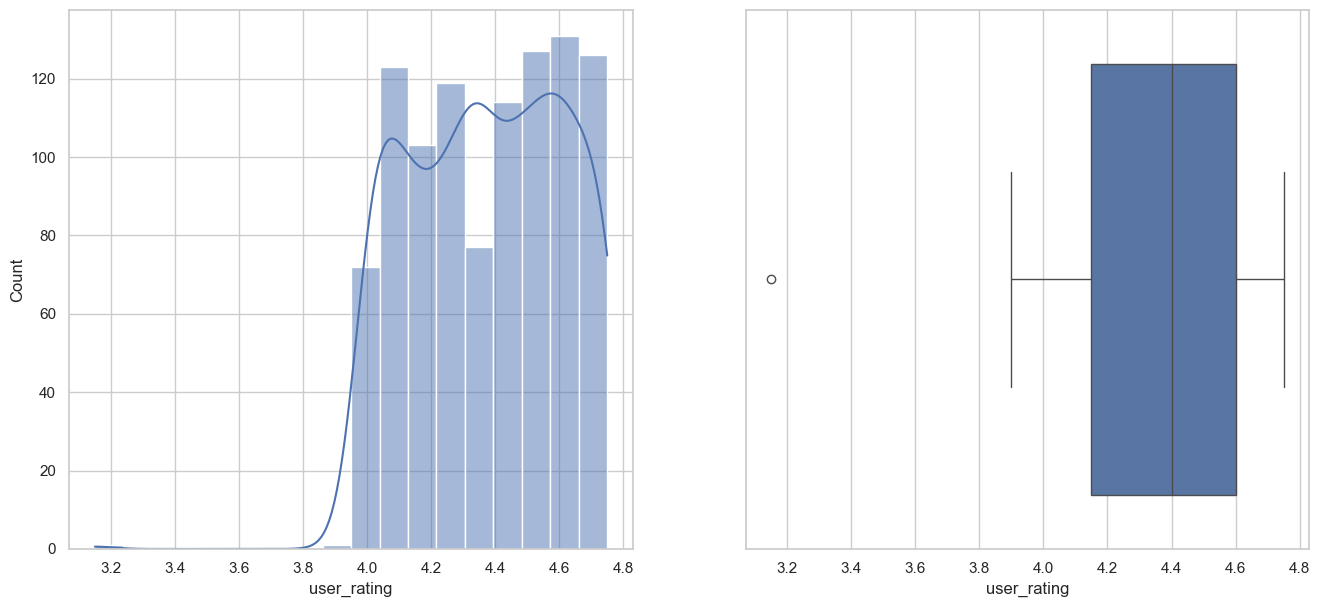

In [29]:
fig,ax = plt.subplots(ncols=2,figsize=(16,7))
sns.histplot(data['user_rating'], kde=True,ax=ax[0])
sns.boxplot(data=data , x='user_rating' , ax=ax[1])
plt.show()

**We see most of the users rated AC between 4 stars and 4.8 stars.**
- Outlier user_rating 3.15 and 3.9 with 1 data each

In [31]:
data['user_rating'].value_counts(ascending=True)
print(f"Skewness->{data['user_rating'].skew()}")
print(f"kurtosis->{data['user_rating'].kurtosis()}")

Skewness->-0.17831386625766754
kurtosis->-0.5659594535827637


### **Discrete Numerical**
**Capacity**

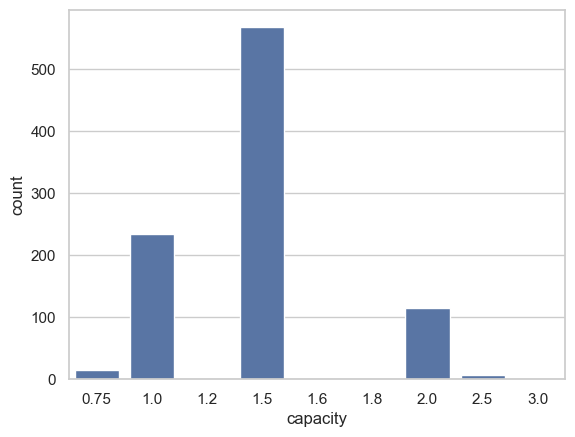

In [32]:
sns.countplot(x=data['capacity'])
plt.show()

- 1.5 Tonne ACs are most in number, followed by 1 Tonne and 2 Tonne
- Data is not uniform with other Tonne having very less in number

### ***Star Ratings***

In [34]:
print(f"Basic Stats :\n{data['star_rating'].describe()}\n")

print(f"Distribution of Star Ratings:\n{data['star_rating'].value_counts()}\n")

Basic Stats :
count       994.0
mean     3.663984
std      0.970756
min           1.0
25%           3.0
50%           3.0
75%           5.0
max           5.0
Name: star_rating, dtype: Float64

Distribution of Star Ratings:
star_rating
3    601
5    326
4     38
2     28
1      1
Name: count, dtype: Int64



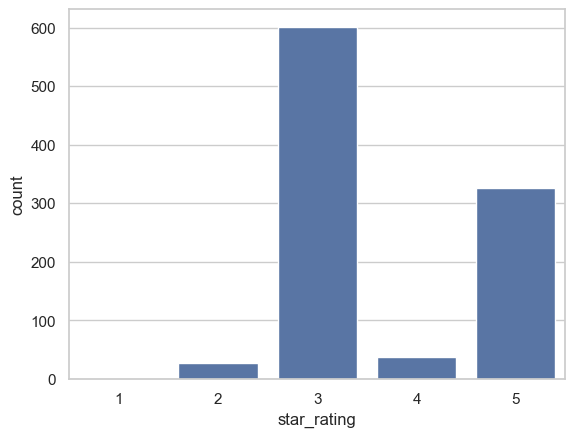

In [33]:
# Plotting the graph
sns.countplot(x =data['star_rating'])
plt.show()

- Most of the ACs are 3 Star ACs with 601 in count, followed by
- 5 Star with 326 and then 4 Star and 2 Star with 38 and 28 respectively.
- There is only 1 AC with 1 Star rating

### Model Year Analysis

Missing model_year: 163
model_year
2018      2
2019      5
2021      5
2022     51
2023    169
2024    126
2025    211
2026    262
Name: count, dtype: Int64


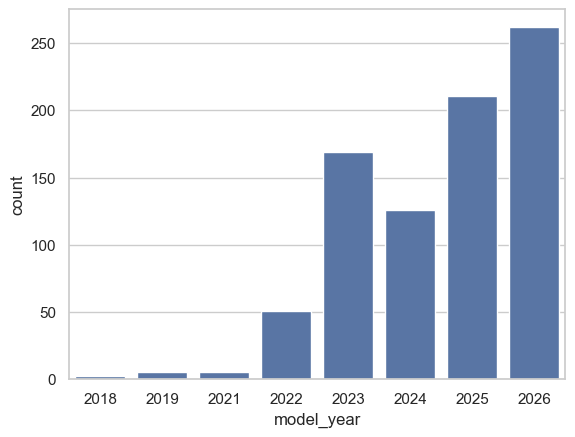

In [35]:
print('Missing model_year:', data['model_year'].isna().sum())
print(data['model_year'].value_counts().sort_index())
sns.countplot(x= data['model_year'])
plt.show()

- Most observations belong to 2023–2026.
- Older years (2018–2021) have almost no samples.
- I would keep it as a numerical feature, not one-hot encode it initially.
Since models like Random Forest and XGBoost can learn the pattern

### Univariate Analysis On Binary Features

Air Swing               89.6
Dehumidification        87.5
Turbo Mode              65.1
Self Diagnosis          46.8
LED Panel Display       21.3
Memory Feature          20.3
Night Glow Buttons      18.6
Wi-Fi Connectivity      18.2
APP Control             18.0
Hidden Panel Display    15.3
Auto Clean              14.9
Voice Control           12.6
PM 2.5 Filter           10.8
dtype: float64


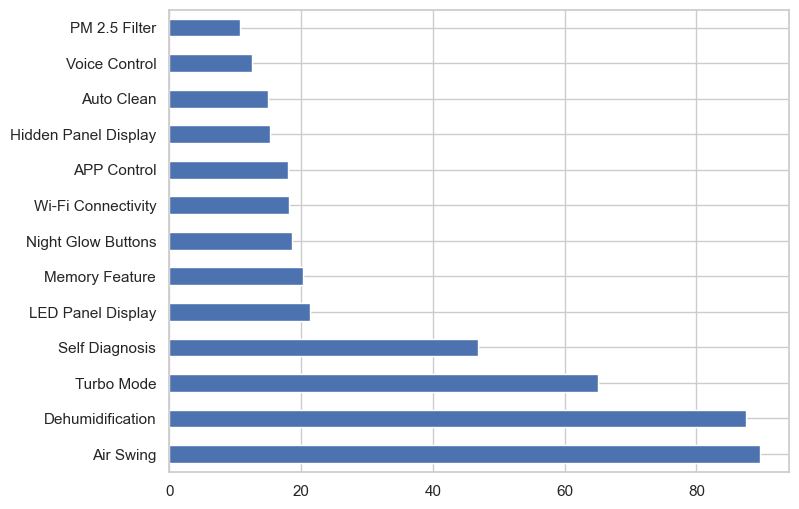

In [38]:
bool_cols = [c for c in data.columns
             if data[c].dtype in ['int64', 'int32']
             and c not in ['price', 'user_rating', 'capacity', 'star_rating',
                           'inverter', 'model_year', 'product']]
prevalence = (data[bool_cols].mean() * 100).sort_values(ascending=False)
print(prevalence.round(1))
prevalence.plot(kind='barh', figsize=(8, 6))
plt.show()


This means:

- Air Swing is present in about 90% of products.
- Dehumidification is present in about 88% of products.
- Turbo Mode is present in about 65% of products.

**So these are the most common features, not necessarily the most premium.**

### To Check the Premium Features, we look for Average prices of ACs for different Features in them

In [39]:
premium_score = {}

for col in bool_cols:
    premium_score[col] = (
        data[data[col] == 1]['price'].mean()
        - data[data[col] == 0]['price'].mean()
    )

pd.Series(premium_score).sort_values(ascending=False)

Voice Control           5519.225841
Wi-Fi Connectivity      4521.562082
APP Control             4373.788210
Air Swing               3577.882024
Hidden Panel Display    3046.790489
LED Panel Display        830.353412
Dehumidification         508.699481
Turbo Mode               235.507151
Night Glow Buttons       -44.565603
Self Diagnosis          -962.940029
Memory Feature         -1160.071082
PM 2.5 Filter          -1565.363211
Auto Clean             -2988.414047
dtype: float64

- This tells the difference in prices if the feature exist in AC vs Not there in AC
-Thus we can say that TOP 3 Premium Features are:
- Voice Control
- WiFi Connectivity
- APP Control

### ***Categorical Columns***

ac_type
Split     888
Window    106
Name: count, dtype: int64
brand
Blue Star    126
Panasonic     86
Godrej        79
Lloyd         78
Voltas        76
Hitachi       69
Daikin        66
Haier         65
Carrier       64
LG            50
Name: count, dtype: int64


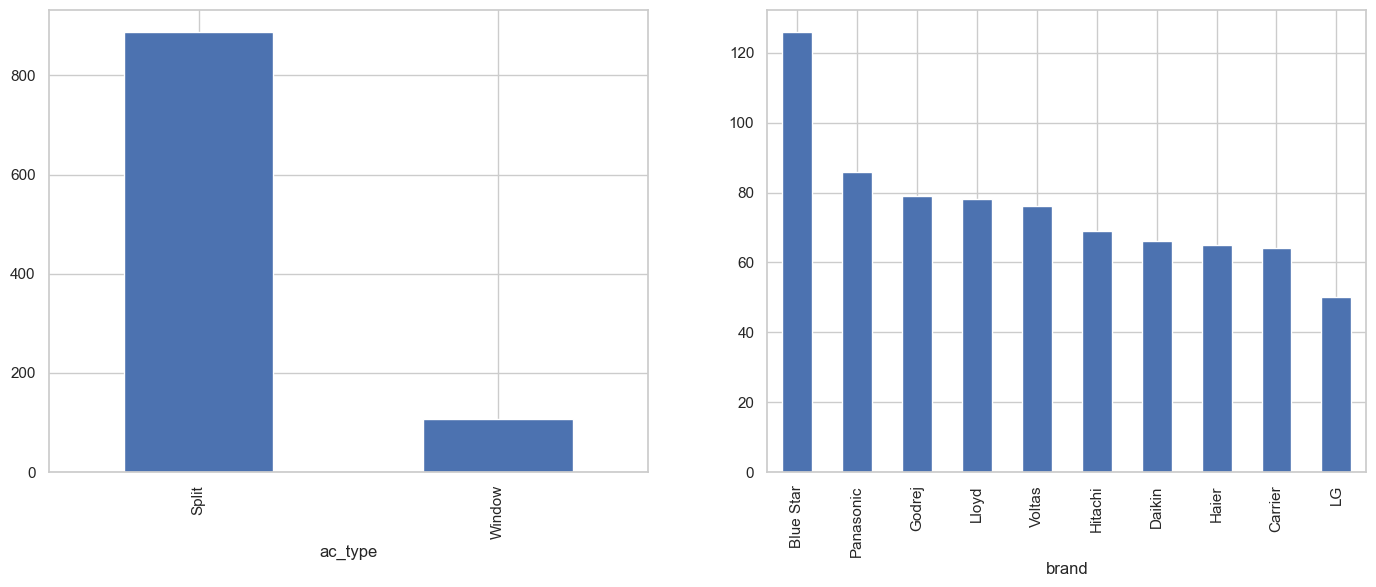

In [59]:
# ac_type
print(data['ac_type'].value_counts())
# brands
print(data['brand'].value_counts().head(10))

fig,ax = plt.subplots(ncols=2 , figsize=(17,6))
data['ac_type'].value_counts().plot(kind='bar' , ax=ax[0])
data['brand'].value_counts().head(10).plot(kind='bar' , ax=ax[1])
plt.show()



# 📊 Univariate EDA — Summary

## **Dataset Snapshot**
- **994 rows × 22 columns** (`ac_cleaned.parquet`)
- 3 categorical (brand, product, ac_type), 19 numeric (2 continuous + 17 discrete)

---

## **1. Price (Target) — ₹**
| Stat | Value |
|---|---|
| Min / Max | ₹19,990 / ₹86,990 |
| Mean | ₹40,201 |
| Median | ₹37,525 |
| 75th pct | ₹44,868 |

**Findings:**
- **Right-skewed** (mean > median, long upper tail)
- 75% of ACs priced below ₹45K
- **Outliers present** but they're genuine premium products (e.g., O General at ₹67,990) → **keep them**
- **Log transform (log1p) normalizes the distribution nicely** → use for linear models

---

## **2. User Rating (Continuous)**
- Range: **3.15 – 4.75** (narrow band)
- Mean: **4.38**, concentrated between 4.0–4.8
- Limited variance → weak individual predictor, but may interact with features

---

## **3. Capacity (Discrete)**
- **1.5T dominates**, then 1T and 2T
- 0.75T, 1.2T, 1.6T, 1.8T, 2.5T, 3.0T have very few samples
- **Imbalanced** — some sizes may need to be grouped during modeling

---

## **4. Star Rating (Discrete)**
| Rating | Count |
|---|---|
| 3★ | 601 (60%) |
| 5★ | 326 (33%) |
| 4★ | 38 |
| 2★ | 28 |
| 1★ | 1 |

- Heavily concentrated at 3★ and 5★; **1★ is essentially noise**

---

## **5. Model Year**
- **16.4% missing** (831/994 non-null)
- 2019–2025 range; most data from 2023–2025
- Boxplot vs price → **price range is nearly flat across years** → weak signal individually
- Plan: brand-median imputation + missing indicator + derive `age`

---

## **6. Binary Features**

**Most prevalent (table-stakes features):**
- Air Swing: ~90%
- Dehumidification: ~88%
- Turbo Mode: ~65%

**Premium features (price uplift when present):**
| Feature | Avg Price Premium |
|---|---|
| 🥇 Voice Control | **+₹5,519** |
| 🥈 Wi-Fi Connectivity | **+₹4,521** |
| 🥉 APP Control | **+₹4,373** |
| Air Swing | +₹3,577 |
| Hidden Panel Display | +₹3,046 |

**Negative-premium features** (actually *cheaper* on average — counter-intuitive, probably correlated with budget brands):
- Auto Clean: −₹2,988
- PM 2.5 Filter: −₹1,565
- Memory Feature: −₹1,160

---

## **Key Takeaways for Modeling**
1. **Log-transform `price`** for linear models (target is skewed)
2. **Don't drop outliers** — they're real premium listings
3. **Capacity is imbalanced** — consider binning rare sizes
4. **Star rating has only 5 levels** — could be treated as ordinal
5. **Handle model_year missingness** explicitly (impute + flag)
6. **Smart/IoT features (Voice, Wi-Fi, App)** are the strongest premium signals
7. Ready to move on to **bivariate analysis** (feature vs. price relationships & correlations)